<a href="https://colab.research.google.com/github/RAJESHKANNA-14/DATA-SCIENCE-/blob/main/image_caption_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import os
import zipfile

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
!wget "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
!unzip -q flickr8k.zip -d ./flickr8k

--2026-05-05 10:00:23--  https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/753516996/d7c62b13-1e50-40ea-8fae-f34a44b1695f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-05T10%3A43%3A23Z&rscd=attachment%3B+filename%3Dflickr8k.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-05T09%3A42%3A30Z&ske=2026-05-05T10%3A43%3A23Z&sks=b&skv=2018-11-09&sig=c1V6IDyFDf5JQDo345%2B6%2BrI55%2Blz5BoqBgOUnOkSOdQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Nzk3ODgyMywibmJmIjoxNzc3OTc1MjIzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

In [3]:
print(os.listdir("flickr8k"))

['captions.txt', 'Images']


In [4]:
print(len(os.listdir("flickr8k/Images")))

8091


In [5]:
files = os.listdir("flickr8k/Images")
print(files[:20])

['2366643786_9c9a830db8.jpg', '2998024845_1529c11694.jpg', '247706586_7e25c7adf8.jpg', '654130822_4aeb1f1273.jpg', '109260216_85b0be5378.jpg', '2355880294_8f78a6fea6.jpg', '1007129816_e794419615.jpg', '2540750172_070250ece5.jpg', '3113769557_9edbb8275c.jpg', '3116011063_f4071ccce6.jpg', '2508313118_524e93d48c.jpg', '3442242092_e579538d82.jpg', '2381583688_a6dd0a7279.jpg', '824923476_d85edce294.jpg', '3415003392_139c0f3586.jpg', '2981702521_2459f2c1c4.jpg', '3111502208_71e2a414f5.jpg', '476233374_e1396998ef.jpg', '2691966747_cfa154982b.jpg', '2187720319_112d00f07d.jpg']


In [6]:
with open("flickr8k/captions.txt","r") as f:
    lines = f.readlines()
print(len(lines))


40456


In [7]:
model = InceptionV3(weights='imagenet')
model = tf.keras.Model(
    model.input,
    model.layers[-2].output
)

model_encoder = model
print("Encoder Loaded")

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Encoder Loaded


In [8]:
def extract_features(directory):

    features={}

    for img in os.listdir(directory)[:100]:
        path=directory+"/"+img

        image=load_img(path,target_size=(299,299))
        image=img_to_array(image)

        image=np.expand_dims(image,axis=0)
        image=preprocess_input(image)

        feature=model.predict(image,verbose=0)

        features[img]=feature

    return features

features = extract_features("flickr8k/Images")
print("Feature extraction completed")

Feature extraction completed


In [9]:
def load_captions(filename):

    mapping={}

    with open(filename,'r') as file:

        for line in file:
            tokens=line.strip().split(',')

            img_id=tokens[0]
            caption=" ".join(tokens[1:])

            if img_id not in mapping:
                mapping[img_id]=[]

            mapping[img_id].append(
                "startseq " + caption + " endseq"
            )

    return mapping

captions=load_captions(
    "flickr8k/captions.txt"
)

print("Captions Loaded")

Captions Loaded


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions=[]

for key in captions:
    for cap in captions[key]:
        all_captions.append(cap)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index)+1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8497


In [11]:
max_length = max(
    len(c.split())
    for c in all_captions
)

print("Max Caption Length:", max_length)

Max Caption Length: 39


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Training data lists
X1 = []
X2 = []
y = []

count = 0

for img, caption_list in captions.items():

    # Skip if image feature not extracted
    if img not in features:
        continue

    for caption in caption_list:

        # Convert caption words to numbers
        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        # Create input-output pairs
        for i in range(1, len(seq)):

            # Input sequence
            in_seq = seq[:i]

            # Next word (target)
            out_seq = seq[i]

            # Pad sequence
            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            # Store training data
            X1.append(features[img][0])
            X2.append(in_seq)

            # Store target as integer
            y.append(out_seq)

    count += 1

    # Use 50 images first to reduce RAM
    if count == 500:
        break


# Convert lists to arrays
X1 = np.array(X1)
X2 = np.array(X2)
y  = np.array(y)

print("Training data ready")
print(X1.shape)
print(X2.shape)
print(y.shape)

Training data ready
(5974, 2048)
(5974, 39)
(5974,)


In [13]:
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add
from tensorflow.keras.models import Model

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256,activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

# FIXED
se1 = Embedding(vocab_size,256)(inputs2)

se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2,se3])
decoder2 = Dense(256,activation='relu')(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1,inputs2],
    outputs=outputs
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 39, 256)   │  2,175,232 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 39, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8497)      │  2,183,729 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,474,609 (20.88 MB)

 Trainable params: 5,474,609 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
model.fit(
    [X1, X2],
    y,
    epochs=25,
    batch_size=32
)

Epoch 1/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 5.6532
Epoch 2/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 4.5274
Epoch 3/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.8899
Epoch 4/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.2902
Epoch 5/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7927
Epoch 6/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.3756
Epoch 7/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0452
Epoch 8/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.7976
Epoch 9/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5768
Epoch 10/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.4198
Epoch 11/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2489
Epoch 12/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1229
Epoch 13/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0005
Epoch 14/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.8912
Epoch 15/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10

In [15]:
def generate_caption(model, image_feature):

    caption = "startseq"

    for i in range(max_length):

        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        seq = pad_sequences(
            [seq],
            maxlen=max_length
        )

        yhat = model.predict(
            [image_feature, seq],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = None

        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break


    # Remove startseq and endseq
    return caption.replace(
        "startseq",""
    ).replace(
        "endseq",""
    ).strip()

In [16]:
test_img = list(features.keys())[65]

print(test_img)

print(
generate_caption(
    model,
    features[test_img]
)
)

2232518012_8cb0bbc43b.jpg
the racing greyhounds have broken from the starting gate


Generated Caption: a man in a red shirt and a red skating is trying to ice ice skating


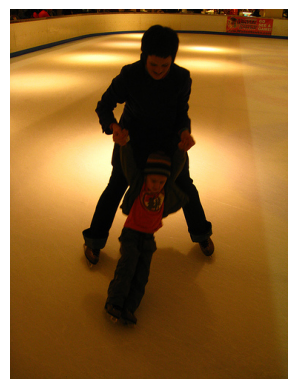

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

test_img = list(features.keys())[43]

img = Image.open(
    "flickr8k/Images/" + test_img
)

plt.imshow(img)
plt.axis("off")

caption = generate_caption(
    model,
    features[test_img]
)

print("Generated Caption:", caption)


In [24]:
from google.colab import files
files.upload()

Saving images (2).jpg to images (2).jpg


{'images (2).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x12\x13\x12\x15\x13\x13\x12\x16\x16\x15\x16\x18\x15\x17\x17\x18\x16\x15\x15\x15\x18\x15\x15\x15\x17\x16\x17\x15\x16\x16\x15\x18\x1d( \x18\x1a%\x1b\x15\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1b\x10\x10\x1b-% %--/-----------------------------------------------\xff\xc0\x00\x11\x08\x00\xe8\x00\xd9\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x02\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x06\x03\x04\x00\x02\x07\x01\x08\xff\xc4\x00C\x10\x00\x01\x03\x02\x04\x03\x06\x03\x04\x08\x04\x05\x05\x00\x00\x00\x01\x00\x02\x11\x03\x04\x05\x12!1\x06AQ\x13"aq\x81\x91\x07\x14\xa12B\xb1\xc1\x15#Rr\x82\x92\xd1\xe1\x16Sb\xf03\xa2\xb2\xd2\xf1\x174\x83\xc3\xd3\xff\xc4\x00\x1a\x01\x00\x02\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x00\x03\x04\x05\x06\xff\xc4\x00+\x11\x00\x02\x02\x02\x02\x01\x04\x01\x02\x07\x01\x00\x00\x00\x00\x0

In [19]:
def extract_feature_single(img_path):

    image = load_img(img_path, target_size=(299,299))
    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    feature = model_encoder.predict(image, verbose=0)

    return feature

Enter image name: images (2).jpg
Generated Caption: a group of people in a black and glasses is standing on a blue store


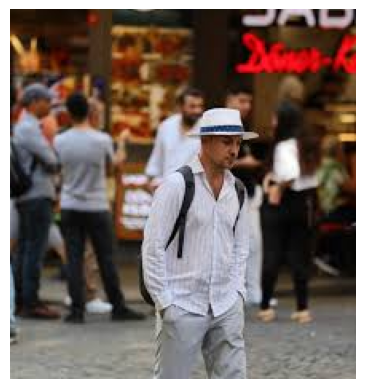

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = input("Enter image name: ")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

feature = extract_feature_single(img_path)
caption = generate_caption(model, feature)

print("Generated Caption:", caption)